In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set a clean style for all charts
sns.set_theme(style="whitegrid", font_scale=1.1)

# Load all your Week 1-3 outputs
master_df = pd.read_csv('master_subscription_data.csv')
retention_pct = pd.read_csv('retention_percentage_matrix.csv', index_col='CohortMonth')
high_value = pd.read_csv('high_value_customers.csv')
top_cohorts = pd.read_csv('top_cohorts.csv')
monthly_ret = pd.read_csv('monthly_retention.csv')

print("All files loaded successfully!")
print("Master data shape:", master_df.shape)

All files loaded successfully!
Master data shape: (5000, 21)


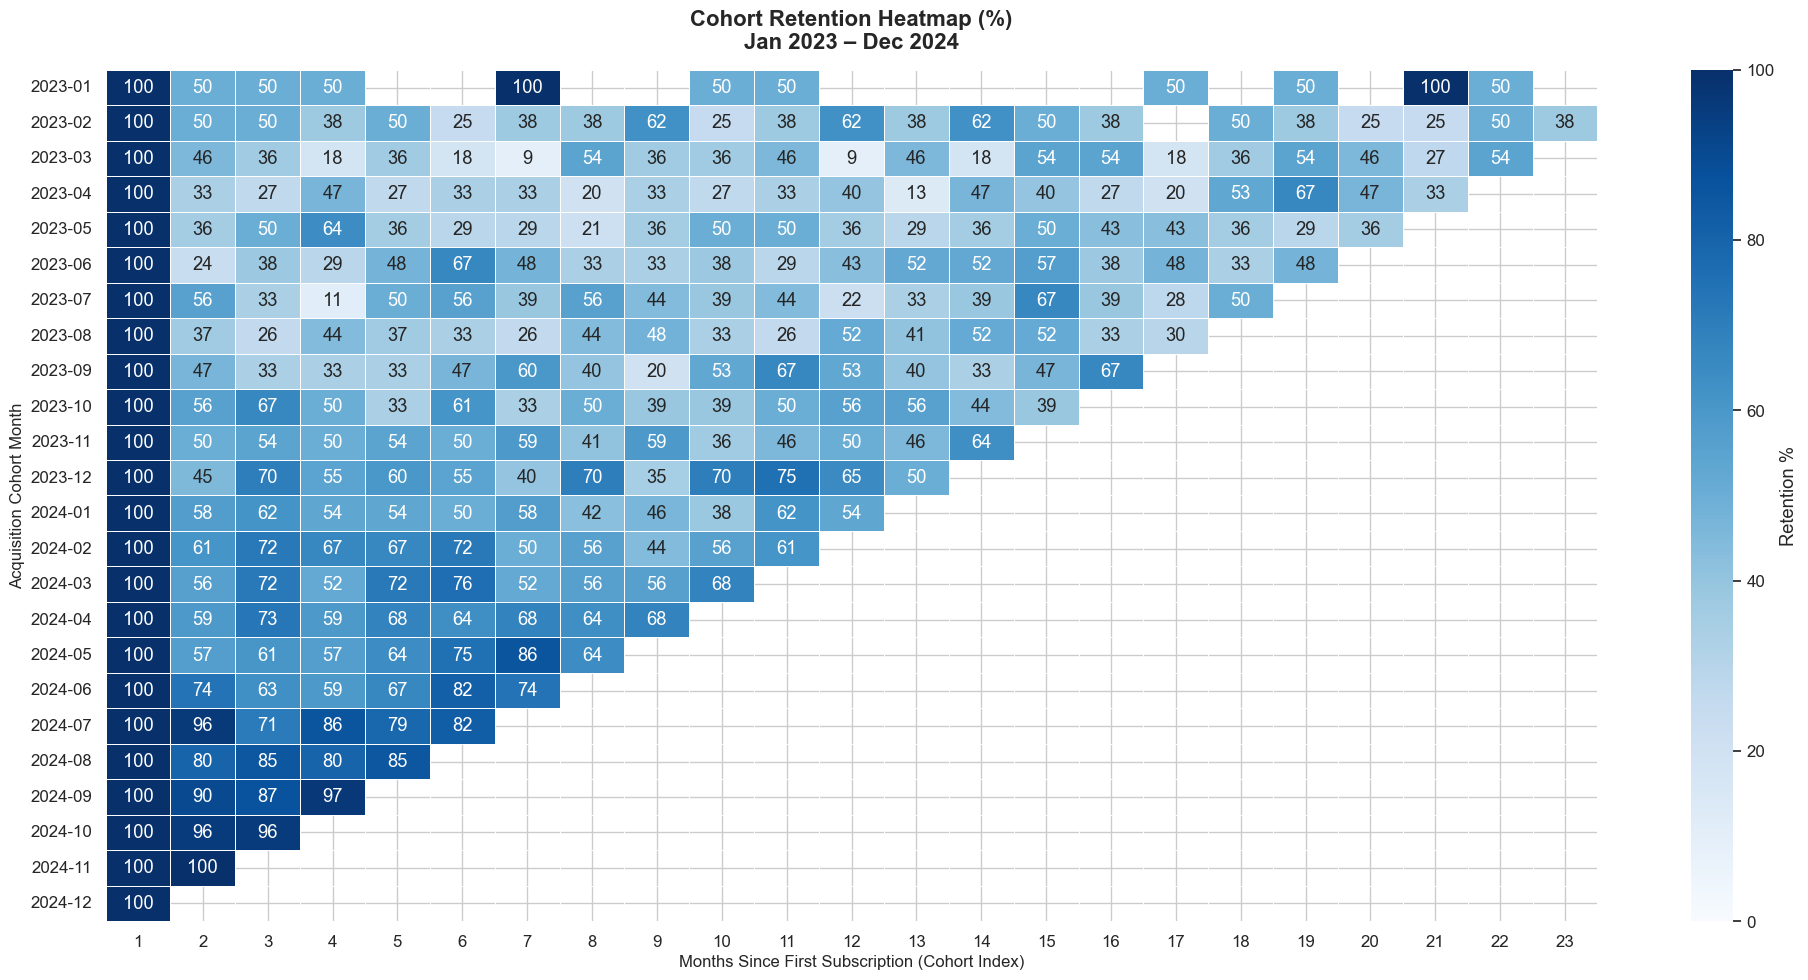

Heatmap saved!


In [2]:
# Convert to percentage format (multiply by 100)
heatmap_data = retention_pct.multiply(100).round(1)

plt.figure(figsize=(20, 10))

sns.heatmap(
    heatmap_data,
    annot=True,           # Show numbers inside cells
    fmt='.0f',            # No decimal places
    cmap='Blues',         # Blue color scale
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Retention %'},
    vmin=0,
    vmax=100
)

plt.title('Cohort Retention Heatmap (%)\nJan 2023 – Dec 2024', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Months Since First Subscription (Cohort Index)', fontsize=12)
plt.ylabel('Acquisition Cohort Month', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cohort_retention_heatmap_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

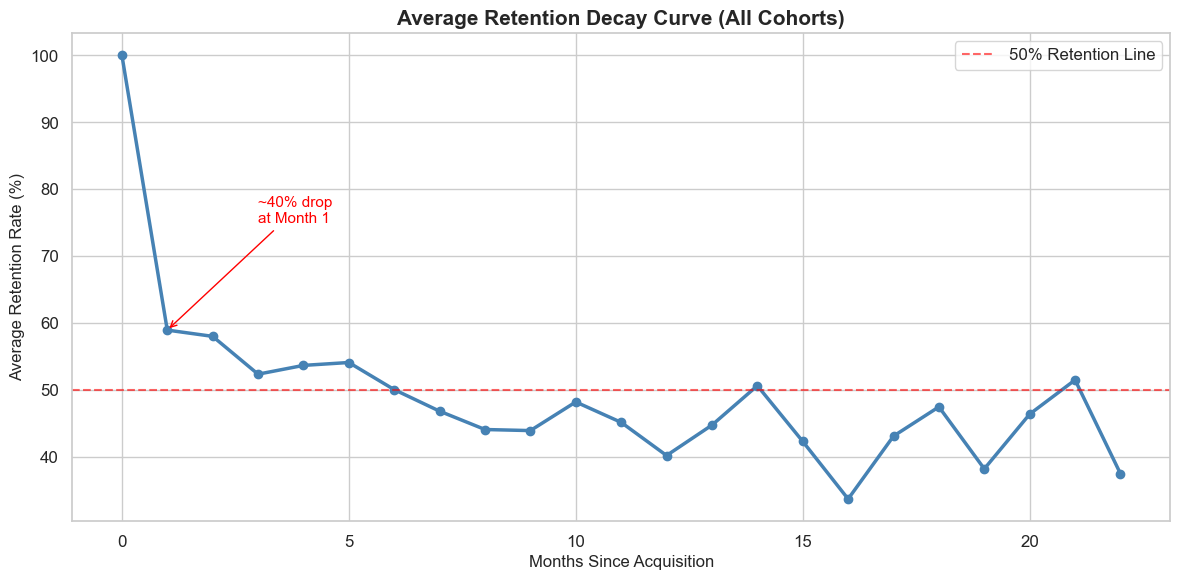

In [3]:
# Use your monthly_retention.csv
monthly_ret.columns = ['CohortIndex', 'AvgRetention']

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_ret['CohortIndex'], 
    monthly_ret['AvgRetention'],
    marker='o',          # Dot at each data point
    linewidth=2.5,
    color='steelblue',
    markersize=6
)

# Add a horizontal reference line at 50%
plt.axhline(y=50, color='red', linestyle='--', alpha=0.6, label='50% Retention Line')

# Annotate the biggest drop (Month 0 to Month 1)
plt.annotate('~40% drop\nat Month 1', 
             xy=(1, monthly_ret['AvgRetention'].iloc[1]),
             xytext=(3, 75),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11, color='red')

plt.title('Average Retention Decay Curve (All Cohorts)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Months Since Acquisition', fontsize=12)
plt.ylabel('Average Retention Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('retention_decay_curve.png', dpi=150, bbox_inches='tight')
plt.show()

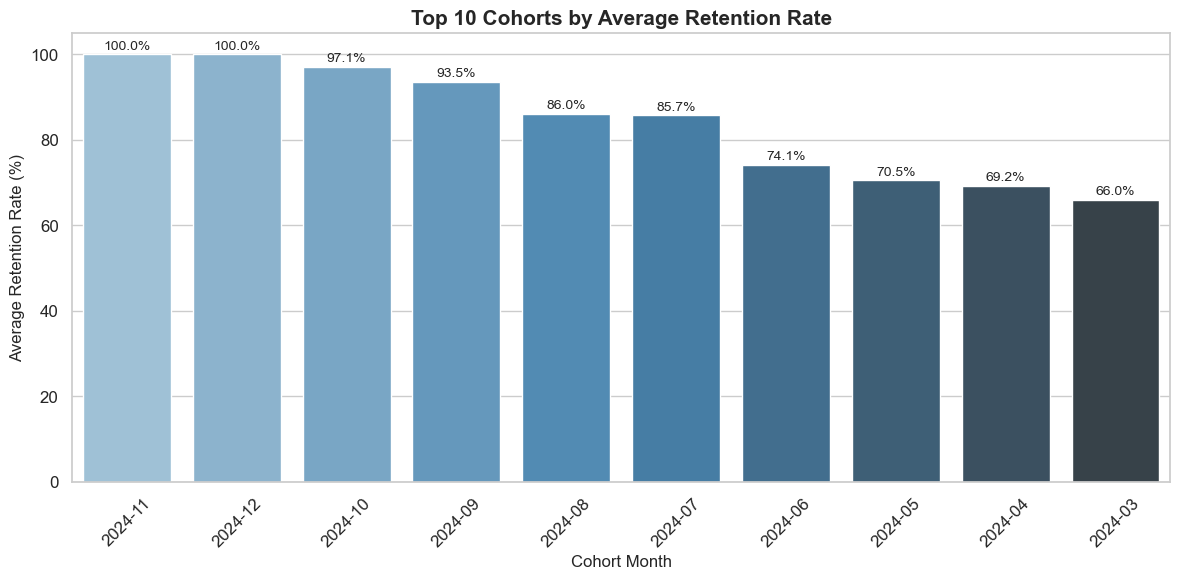

In [4]:
# top_cohorts.csv already has average retention per cohort
top_cohorts.columns = ['CohortMonth', 'AvgRetention']
top_cohorts_sorted = top_cohorts.sort_values('AvgRetention', ascending=False).head(10)

plt.figure(figsize=(12, 6))

bars = sns.barplot(
    data=top_cohorts_sorted,
    x='CohortMonth',
    y='AvgRetention',
    palette='Blues_d'
)

# Add value labels on each bar
for bar, val in zip(bars.patches, top_cohorts_sorted['AvgRetention']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.5,
              f'{val:.1f}%',
              ha='center', va='bottom', fontsize=10)

plt.title('Top 10 Cohorts by Average Retention Rate', 
          fontsize=15, fontweight='bold')
plt.xlabel('Cohort Month', fontsize=12)
plt.ylabel('Average Retention Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_cohorts_bar.png', dpi=150, bbox_inches='tight')
plt.show()

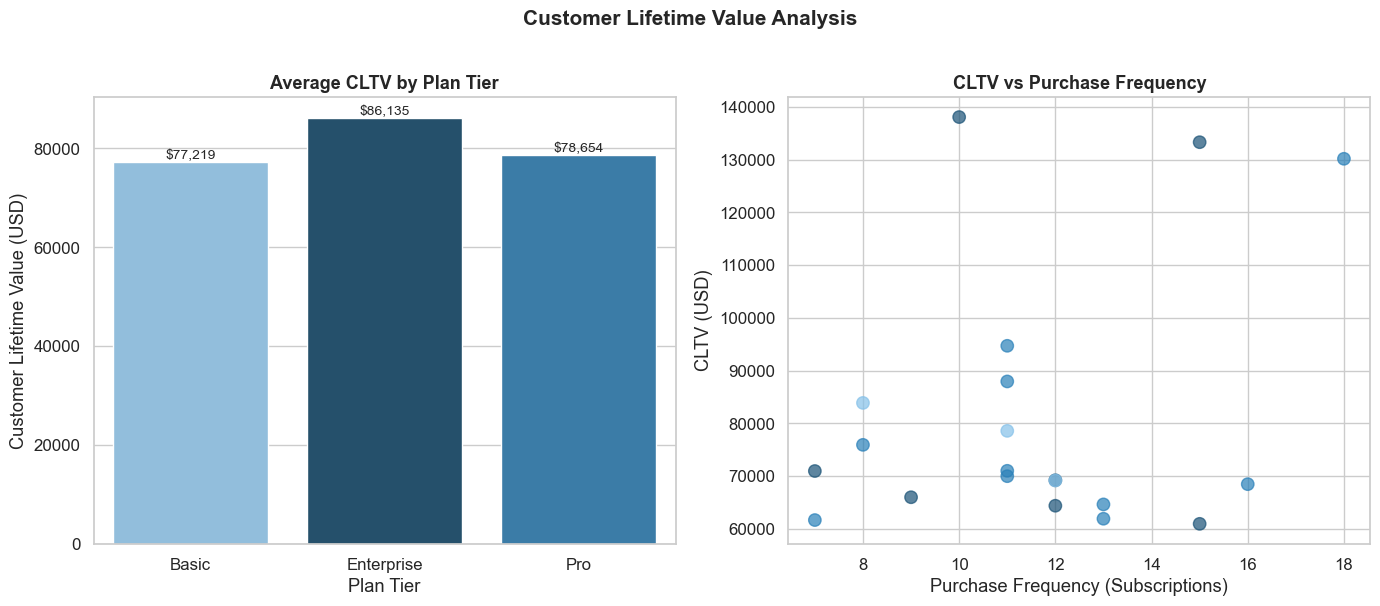

In [5]:
# From high_value_customers.csv
# Segment by PlanTier
cltv_by_tier = high_value.groupby('PlanTier')['CLTV'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: CLTV by Plan Tier
sns.barplot(
    data=cltv_by_tier,
    x='PlanTier',
    y='CLTV',
    palette={'Enterprise': '#1a5276', 'Pro': '#2980b9', 'Basic': '#85c1e9'},
    ax=axes[0]
)
axes[0].set_title('Average CLTV by Plan Tier', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Plan Tier')
axes[0].set_ylabel('Customer Lifetime Value (USD)')

# Add value labels
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():,.0f}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

# Chart 2: CLTV distribution scatter
axes[1].scatter(
    high_value['PurchaseFrequency'],
    high_value['CLTV'],
    c=high_value['PlanTier'].map({'Enterprise': '#1a5276', 'Pro': '#2980b9', 'Basic': '#85c1e9'}),
    alpha=0.7,
    s=80
)
axes[1].set_title('CLTV vs Purchase Frequency', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Purchase Frequency (Subscriptions)')
axes[1].set_ylabel('CLTV (USD)')

plt.suptitle('Customer Lifetime Value Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cltv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

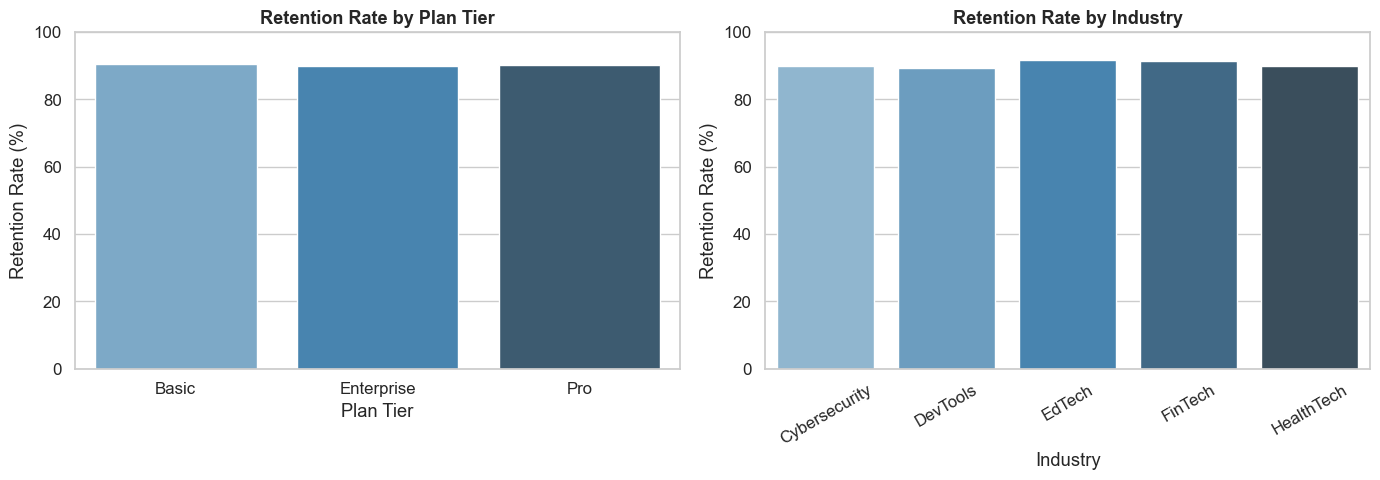

In [6]:
# Retention by plan tier
tier_churn = master_df.groupby('plan_tier')['churn_flag'].mean().reset_index()
tier_churn['retention'] = (1 - tier_churn['churn_flag']) * 100

# Retention by industry
industry_churn = master_df.groupby('industry')['churn_flag'].mean().reset_index()
industry_churn['retention'] = (1 - industry_churn['churn_flag']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plan Tier
sns.barplot(data=tier_churn, x='plan_tier', y='retention',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Retention Rate by Plan Tier', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Plan Tier')
axes[0].set_ylabel('Retention Rate (%)')
axes[0].set_ylim(0, 100)

# Industry
sns.barplot(data=industry_churn, x='industry', y='retention',
            palette='Blues_d', ax=axes[1])
axes[1].set_title('Retention Rate by Industry', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Industry')
axes[1].set_ylabel('Retention Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('retention_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()